Key point:

preprocessing:

- boolean type:
    - False -> 0; True -> 1
- categories:
    - orbital_period_cat & dist_category: transform to ordinal based on number(period length/distance) itself
    - others: combine those occur less than 50 times to a catogory 'Other', then one-hot encoding is applied

3 models:
- SVC with default parameters
- SMOTE + SVC with default parameters
- grid search + SVC, optimized with F1 score (improve precision rate at the cost of recall rate)

performance:


| Metric        | Baseline | +SMOTE | Grid Search + SMOTE |
|---------------|---------:|-------:|--------------------:|
| Accuracy      | 0.9047   | 0.9193 | **0.9386**          |
| Precision     | 0.4294   | 0.4710 | **0.5476**          |
| Recall        | **0.9620** | 0.9241 | 0.8734             |
| F1 Score      | 0.5938   | 0.6239 | **0.6732**          |
| ROC-AUC       | 0.9719   | 0.9726 | **0.9742**          |
| Avg Precision | 0.7573   | 0.7660 | **0.7780**          |

based on the permutation importance, orbital period, semi major axis, star_vmag and star temperature are effective indicators.

AUC is around 97% for three models


further improvement
- threshold tuning to find a threshold that maximize f1 score or satisfies a recall >90% constraint.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_cleaned = pd.read_csv('exoplanet_clean.csv')
df = df_cleaned.copy()

convert categories to int, get data ready for modelling

In [2]:
num_cols = ['orbital_period_days', 'planet_radius_earth', 'planet_mass_earth',
            'semi_major_axis_au', 'star_temp_k', 'star_radius_sun',
            'star_mass_sun', 'star_surface_gravity', 'star_metallicity',
            'star_vmag', 'dist_from_earth_pc']
bool_cols = ['habitable_zone_flag','multi_planet_system','is_recent_discovery']
cat_cols = ['planet_type','star_type','discovery_method','dist_category',
            'orbital_period_cat']

In [3]:
for cat in cat_cols:
    print(df[cat].value_counts(),'\n')

planet_type
Mini-Neptune     1987
Gas Giant        1419
Super-Earth      1082
Neptune-like      418
Super-Jupiter     294
Sub-Earth         215
Unknown            36
Name: count, dtype: int64 

star_type
G-type(Sun-like)     2515
K-type               1521
F-type               1036
M-type(Red Dwarf)     353
A-type                 19
B-type                  5
O-type                  2
Name: count, dtype: int64 

discovery_method
Transit                          4258
Radial Velocity                  1129
Transit Timing Variations          34
Imaging                            17
Eclipse Timing Variations           6
Orbital Brightness Modulation       3
Astrometry                          3
Pulsation Timing Variations         1
Name: count, dtype: int64 

dist_category
Far(500-2kpc)     2178
Mid(100-500pc)    1790
Nearby(<100pc)    1405
Distant(2k+pc)      63
Unknown             15
Name: count, dtype: int64 

orbital_period_cat
Short(1-10d)        2429
Medium(10-100d)     1964
Very-Long(3

In [4]:
# categories with clear order
dist_order = {
    'Nearby(<100pc)': 0,
    'Mid(100-500pc)': 1,
    'Far(500-2kpc)': 2,
    'Distant(2k+pc)':3,
    'Unknown': 1    # map 'Unknown' distance to 1 (Mid-range) as a conservative median assumption;
}
df['dist_category'] = df['dist_category'].map(dist_order)

period_order = {
    'Ultra-Short(<1d)': 0,
    'Short(1-10d)': 1,
    'Medium(10-100d)': 2,
    'Long(100-365d)': 3,
    'Very-Long(365d+)': 4,
}
df['orbital_period_cat'] = df['orbital_period_cat'].map(period_order)

In [5]:
# define 'True' as 1, 'False' as 0 to the columns with boolean type
df[bool_cols] = df[bool_cols].astype(int)

In [6]:
# for the rest columns, we combine the categories occurs less than 50 times, and apply one-hot encoding
one_hot_cols = ['planet_type', 'star_type', 'discovery_method']

for col in one_hot_cols:
    cur_col = df[col]
    combined_cat = cur_col.value_counts()[lambda x: x<50].index
    cur_col = cur_col.replace(combined_cat, 'Other')
    dummies = pd.get_dummies(cur_col, prefix = col).astype(int)
    df = pd.concat([df, dummies], axis = 1)

df = df.drop(columns = one_hot_cols)

In [7]:
for col in one_hot_cols:
    print(df.filter(regex=col).sum(), '\n')
print(df.info())
# all the data type is int64/float64

planet_type_Gas Giant        1419
planet_type_Mini-Neptune     1987
planet_type_Neptune-like      418
planet_type_Other              36
planet_type_Sub-Earth         215
planet_type_Super-Earth      1082
planet_type_Super-Jupiter     294
dtype: int64 

star_type_F-type               1036
star_type_G-type(Sun-like)     2515
star_type_K-type               1521
star_type_M-type(Red Dwarf)     353
star_type_Other                  26
dtype: int64 

discovery_method_Other                64
discovery_method_Radial Velocity    1129
discovery_method_Transit            4258
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   n_stars                           5451 non-null   int64  
 1   n_planets                         5451 non-null   int64  
 2   orbital_period_days               5451 non-null   

In [8]:
# Snapshot of encoded DataFrame before feature engineering
df_intact = df.copy()

In [9]:
# I just copy the feature engineering coding and paste it here

# transform family
# applying log transformations
log_cols = ['orbital_period_days', 'planet_mass_earth', 'semi_major_axis_au', 'dist_from_earth_pc']

for col in log_cols:
    df[f'log_{col}'] = np.log10(df[col] + 1e-6)
# ratio family
# density
df['planet_density_proxy'] = df['planet_mass_earth'] / (df['planet_radius_earth'] ** 3)

# Flux
# Formula: (Star Temperature / Sun Temp)^4 * (Star Radius)^2 / (Distance)^2
df['stellar_flux'] = ((df['star_temp_k'] / 5778) ** 4 * (df['star_radius_sun'] ** 2)) / (df['semi_major_axis_au'] ** 2)

# Relative Distance
df['rel_dist_to_star_mass'] = df['semi_major_axis_au'] / df['star_mass_sun']


# drop the features that are highly correlated to others
drop_cols = ['planet_mass_earth', 'semi_major_axis_au', 'star_mass_sun',
             'star_surface_gravity']
df = df.drop(columns = drop_cols)

SVM
- model1: baseline model with default parameters

In [10]:
from sklearn.model_selection import train_test_split


X = df.drop(columns = ['habitable_zone_flag'])
y = df['habitable_zone_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4360, 35) (1091, 35) (4360,) (1091,)


In [11]:
cols = X.columns
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import confusion_matrix, roc_auc_score


def svc_model(X_train, X_test, y_train, kernel = 'rbf', C = 1):
    # class_weight = 'balanced' adjusts weights inversely proportional to class frequency
    svc = SVC(kernel = kernel, C = C, class_weight= 'balanced', random_state=42)
    svc.fit(X_train,y_train)
    y_pred = svc.predict(X_test)
    y_score = svc.decision_function(X_test)
    return y_pred, y_score, svc

y_baseline, y_baseline_score, model_baseline= svc_model(X_train, X_test, y_train)

In [24]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

def compute_performance(y_true, y_pred, y_score):
    fig, axes = plt.subplots(1, 3, figsize = (16, 4))

    confusion_mat = confusion_matrix(y_true,y_pred)
    sns.heatmap(confusion_mat, fmt = 'd', annot = True, cmap='Blues',
                xticklabels=['0', '1'], yticklabels=['0', '1'], ax = axes[0])
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')
    axes[0].set_title('Confusion matrix')

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label = f'AUC = {roc_auc:.4f}')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (FPR)')
    axes[1].set_ylabel('True Positive Rate (TPR)')
    axes[1].legend(loc = 'lower right')
    axes[1].set_title('Receiver Operating Characteristic (ROC)')

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    ax2 = axes[2].twinx()
    line1 = axes[2].plot(thresholds, precision[:-1], label = 'Precision', color = 'red')
    line2 = ax2.plot(thresholds, recall[:-1], label = 'Recall')

    line = line1 + line2
    line_label = [l.get_label() for l in line]
    axes[2].legend(handles = line, labels = line_label, loc = 'center left')
    axes[2].set_title('Precision-Recall curve')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Precision')
    ax2.set_ylabel('Recall')

    plt.tight_layout()
    plt.show()
    print(f"accuracy score {metrics.accuracy_score(y_true, y_pred):.4f}")
    print(f"precision score {metrics.precision_score(y_true, y_pred):.4f}")
    print(f"recall score {metrics.recall_score(y_true, y_pred):.4f}")
    print(f"f1 score {metrics.f1_score(y_true, y_pred):.4f}")
    print(f'AUC = {roc_auc:.4f}')
    print(f"average precision score {metrics.average_precision_score(y_true, y_score):.4f}")

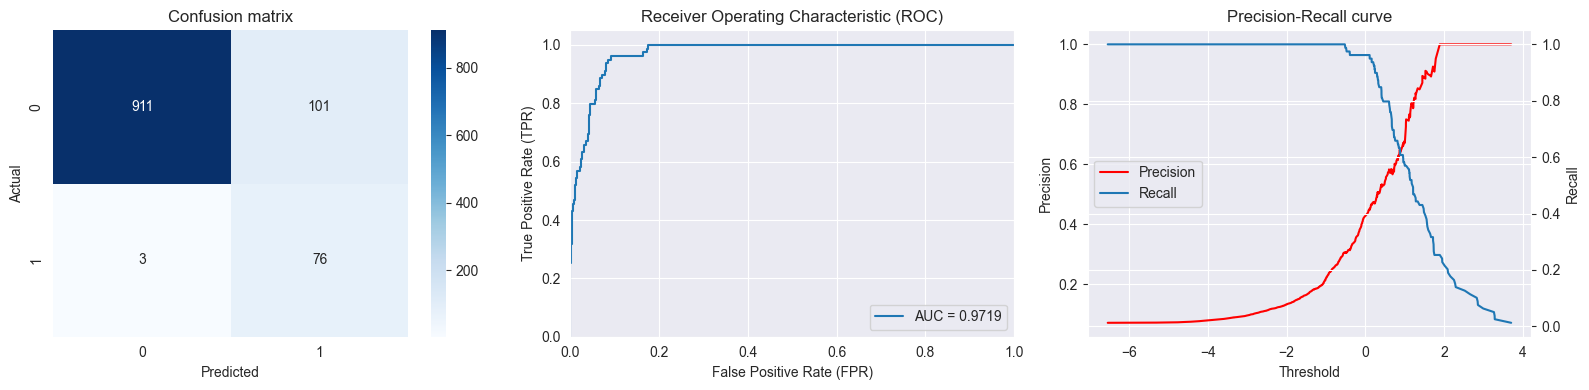

accuracy score 0.9047
precision score 0.4294
recall score 0.9620
f1 score 0.5938
AUC = 0.9719
average precision score 0.7573


In [25]:
compute_performance(y_test, y_baseline, y_baseline_score)

even for the default model, the performance is not poor except for the precision rate.

SMOTE is applied to mitigate imbalance, and improvement is expected.

- model2: applying the SMOTE to mitigate imbalance, using default parameters

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy= 0.5, random_state=42, k_neighbors=4)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(X_train.shape, y_train.shape)
print(X_train_resampled.shape, y_train_resampled.shape)
print(y_train.sum(), y_train_resampled.sum())


(4360, 35) (4360,)
(6069, 35) (6069,)
314 2023


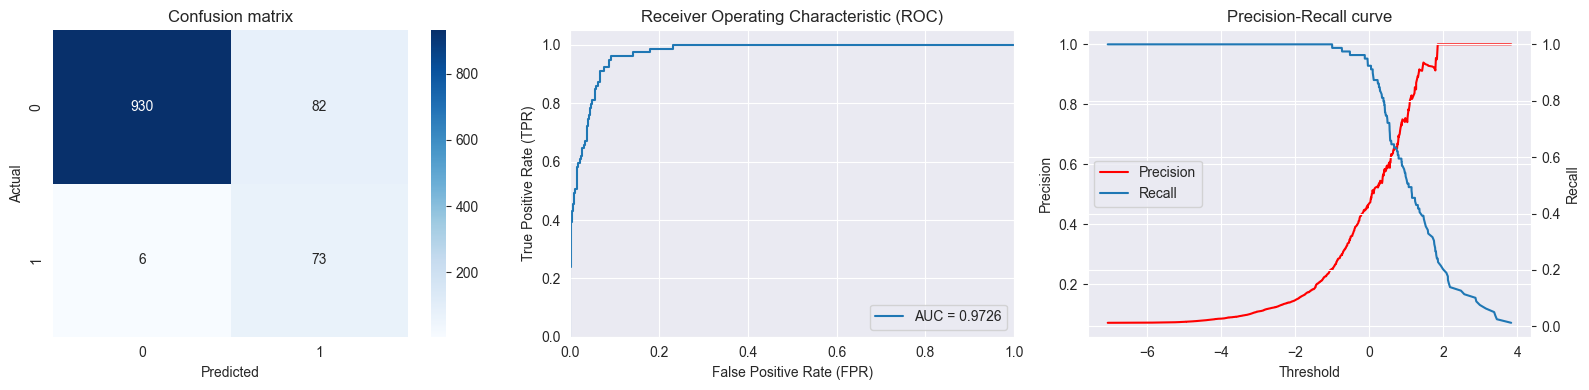

accuracy score 0.9193
precision score 0.4710
recall score 0.9241
f1 score 0.6239
AUC = 0.9726
average precision score 0.7660


In [26]:
y_baseline2, y_baseline2_score, model_baseline2 = svc_model(X_train_resampled, X_test, y_train_resampled)
compute_performance(y_test, y_baseline2, y_baseline2_score)

While the recall rate drops about 3%, f1 score rises from 58% to 63% and precision rate is improved by 6%.
This result shows that SMOTE is useful for imbalanced data.

If we are expected to strike a balance between recall rate(correctly predict a planet suitable for human habitalization) and precision rate (measure the cost of excluding inaccurate prediction), grid search optimizing f1 score can be implemented to achieve a trade-off.


- model3: use grid search to find a model gain a maximum f1 score

In [28]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline


pipeline = Pipeline([
    # unlike the model2, SMOTE is applied inside the pipeline
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(class_weight='balanced', random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'smote__sampling_strategy': [0.3, 0.5],
    'smote__k_neighbors': [4, 5],
    'svc__C':      [0.1, 0.5, 1, 5],
    'svc__kernel': ['rbf', 'poly', 'sigmoid'],
    'svc__gamma':  ['scale', 'auto', 0.01, 0.1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv = cv,
    scoring = 'f1',
    n_jobs = -1
)

grid.fit(X_train, y_train)
grid.best_params_


{'smote__k_neighbors': 4,
 'smote__sampling_strategy': 0.5,
 'svc__C': 5,
 'svc__gamma': 'auto',
 'svc__kernel': 'rbf'}

In [29]:
print(f'best CV F1 score in training set: {grid.best_score_:.4f}')

best CV F1 score in training set: 0.6934


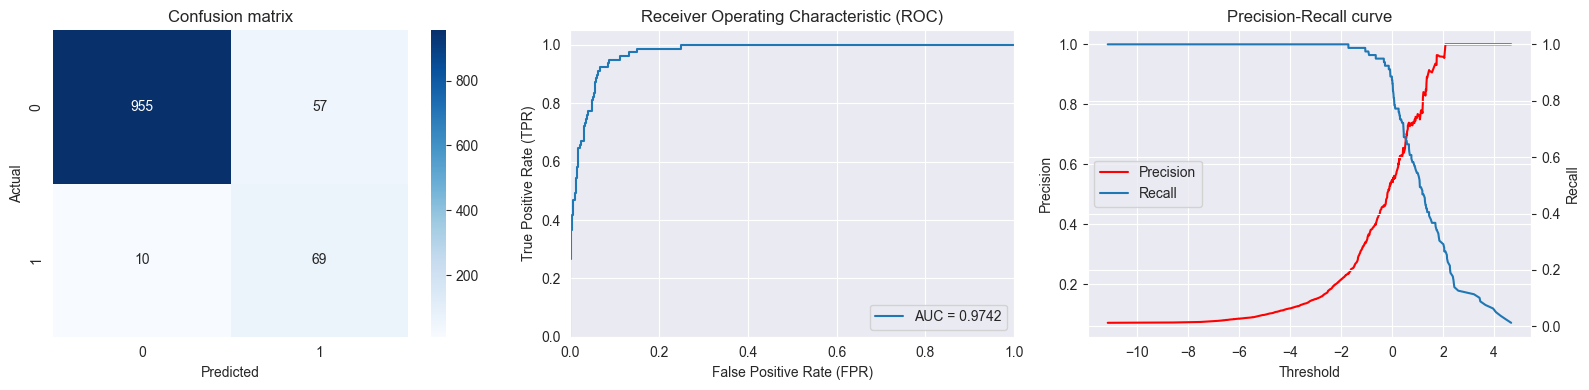

accuracy score 0.9386
precision score 0.5476
recall score 0.8734
f1 score 0.6732
AUC = 0.9742
average precision score 0.7780


In [30]:
model_best = grid.best_estimator_
y_best = model_best.predict(X_test)
y_best_score = model_best.decision_function(X_test)
compute_performance(y_test, y_best, y_best_score)

F1 score difference between train set and test set is small than 5%, indicating less likely to be overfitted

recall rate drops to 87%, approximately 10% lower, and precision score is improved by 10%.

AUC of the three models are around 97%, this may be due to imbalanced frequency, average precision rate could be a more valuable indicator instead.

If necessary, I can do the threshold tuning to find the threshold(rather than default value 0) that maximises f1 score or satisfies a recall >90% constraint.

In [17]:
from sklearn.inspection import permutation_importance

def permutation_plot(model, X_test, y_test, feature_name):
    result = permutation_importance(model, X_test, y_test,
                                    n_repeats=30, scoring='f1', random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'feature': feature_name,
        'importance': result.importances_mean,
        'std': result.importances_std
    }).sort_values('importance', ascending=False)

    top = perm_df.head(10)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(top['feature'], top['importance'], xerr=top['std'])
    ax.set_xlabel('Mean decrease in F1')
    ax.set_title('Permutation Importance (Top 10 Features)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


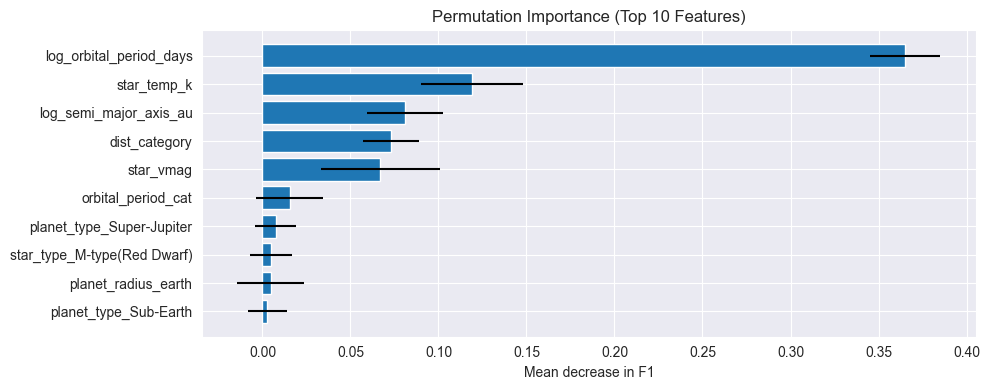

In [21]:
permutation_plot(model_best, X_test, y_test, cols)

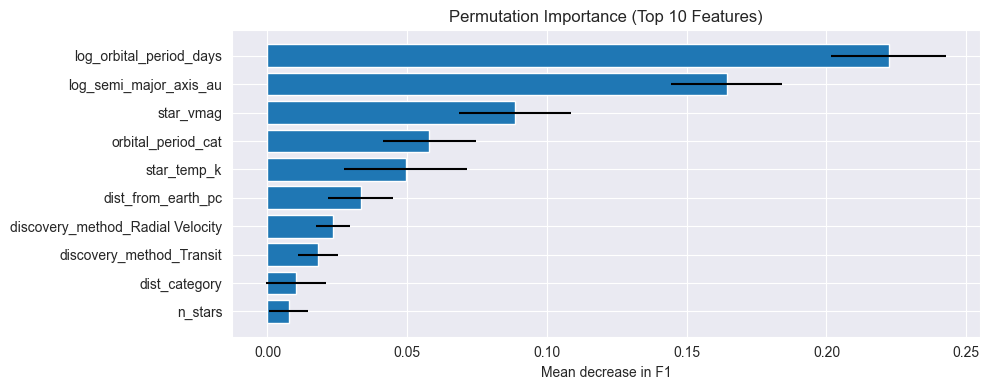

In [22]:
permutation_plot(model_baseline, X_test, y_test, cols)

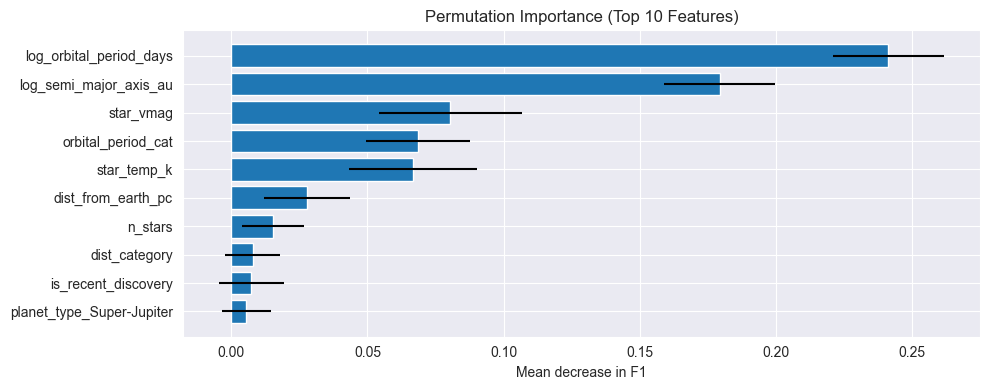

In [18]:
permutation_plot(model_baseline2, X_test, y_test, cols)

considering the features that have a distinct impact(>0.05) on the f1 score, the baseline model and the model3 align with the observation that orbital period, semi major axis, star_vmag and star temperature are effective indicators.


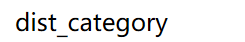